<a href="https://colab.research.google.com/github/mustafemohamedmalinm-lgtm/bioinformatics-beginning-/blob/main/Predicting_Disease_Recovery_Using_Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- EPIDEMIOLOGY MODEL START ---
Basic Reproduction Number (R0): 2.9999999999999996
An R0 of 2.9999999999999996 means each infected person infects 2.9999999999999996 others on average.

Simulation complete. Showing the epidemic curve graph...


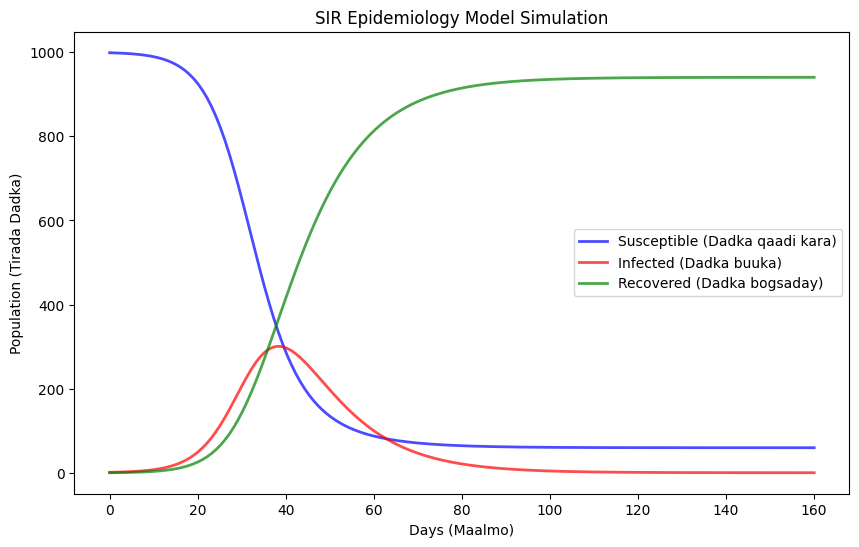

In [2]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

def sir_model(y, t, N, beta, gamma):
    """
    Defines the differential equations for the SIR epidemiology model.
    """
    S, I, R = y

    # Differential equations for SIR
    dSdt = -beta * S * I / N
    dIdt = (beta * S * I / N) - (gamma * I)
    dRdt = gamma * I

    return dSdt, dIdt, dRdt

def run_epidemic_simulation():
    # 1. Population and Initial Conditions
    N = 1000        # Total population (e.g., a small town of 1000 people)
    I0 = 1          # Initial number of infected people
    R0 = 0          # Initial number of recovered people
    # Everyone else is susceptible initially
    S0 = N - I0 - R0

    # 2. Disease Characteristics (Parameters)
    # beta: Contact rate (how fast the disease spreads from person to person)
    # gamma: Recovery rate (1 / days to recover. e.g., 1/10 means 10 days to recover)
    beta = 0.3
    gamma = 0.1

    # Calculate Basic Reproduction Number (R0)
    basic_reproduction_number = beta / gamma
    print(f"--- EPIDEMIOLOGY MODEL START ---")
    print(f"Basic Reproduction Number (R0): {basic_reproduction_number}")
    print(f"An R0 of {basic_reproduction_number} means each infected person infects {basic_reproduction_number} others on average.\n")

    # 3. Timeframe for the simulation (0 to 160 days)
    t = np.linspace(0, 160, 160)

    # Initial conditions vector
    y0 = (S0, I0, R0)

    # 4. Integrate the SIR equations over the time grid t
    ret = odeint(sir_model, y0, t, args=(N, beta, gamma))
    S, I, R = ret.T

    # 5. Plot the results using Matplotlib
    plt.figure(figsize=(10, 6))
    plt.plot(t, S, 'b', alpha=0.7, linewidth=2, label='Susceptible (Dadka qaadi kara)')
    plt.plot(t, I, 'r', alpha=0.7, linewidth=2, label='Infected (Dadka buuka)')
    plt.plot(t, R, 'g', alpha=0.7, linewidth=2, label='Recovered (Dadka bogsaday)')

    plt.xlabel('Days (Maalmo)')
    plt.ylabel('Population (Tirada Dadka)')
    plt.title('SIR Epidemiology Model Simulation')
    plt.legend(True)

    print("Simulation complete. Showing the epidemic curve graph...")
    plt.show(True)

if __name__ == "__main__":
    run_epidemic_simulation()

In [5]:
!pip install scikit-learn

In [6]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. VILLAGE DATA GENERATION (Synthetic Data)
np.random.seed(42)
n_people = 1000

# Age of the villagers (between 1 and 90 years old)
ages = np.random.randint(1, 90, n_people)

# Vaccination Status: 1 = Vaccinated, 0 = Not Vaccinated (50/50 split)
vaccinated = np.random.choice([0, 1], size=n_people, p=[0.5, 0.5])

# Recovery (Target Variable):
# Villagers have a higher chance to recover (1) if they are vaccinated or young.
# Elderly unvaccinated villagers face a higher risk of not recovering (0).
recovered = []
for i in range(n_people):
    if vaccinated[i] == 1:
        # Vaccine gives a 90% chance of recovery
        recovered.append(np.random.choice([1, 0], p=[0.9, 0.1]))
    else:
        # Unvaccinated recovery depends heavily on age
        if ages[i] < 50:
            recovered.append(np.random.choice([1, 0], p=[0.7, 0.3]))
        else:
            recovered.append(np.random.choice([1, 0], p=[0.3, 0.7]))

# Convert the data into a structured table (Pandas DataFrame)
village_data = pd.DataFrame({
    'Age': ages,
    'Vaccinated': vaccinated,
    'Recovered': recovered
})

# 2. MACHINE LEARNING WORKFLOW
# X = Features the model looks at (Age, Vaccinated)
# y = Target the model wants to predict (Recovered)
X = village_data[['Age', 'Vaccinated']]
y = village_data['Recovered']

# Split data: 80% for Training the model, 20% for Testing its accuracy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Choose the ML Algorithm (Random Forest Classifier)
ml_model = RandomForestClassifier(random_state=42)

# Train the model (Let it find patterns in the data)
ml_model.fit(X_train, y_train)

# Evaluate the model's performance
predictions = ml_model.predict(X_test)
accuracy = accuracy_score(y_test, predictions) * 100

print(f"--- MACHINE LEARNING MODEL TRAINED ---")
print(f"Model Accuracy: {accuracy:.2f}%\n")

# 3. MAKING PREDICTIONS FOR NEW PATIENTS
print("--- MAKING PREDICTIONS FOR NEW PATIENTS ---")

# Patient 1: An elderly 75-year-old who IS VACCINATED (Age=75, Vaccinated=1)
elderly_vaccinated = [[75, 1]]
prediction_1 = ml_model.predict(elderly_vaccinated)
print(f"Patient 1 (75yo, Vaccinated): {'RECOVERED' if prediction_1[0] == 1 else 'NOT RECOVERED / HIGH RISK'}")

# Patient 2: An elderly 75-year-old who IS NOT VACCINATED (Age=75, Vaccinated=0)
elderly_unvaccinated = [[75, 0]]
prediction_2 = ml_model.predict(elderly_unvaccinated)
print(f"Patient 2 (75yo, NOT Vaccinated): {'RECOVERED' if prediction_2[0] == 1 else 'NOT RECOVERED / HIGH RISK'}")

--- MACHINE LEARNING MODEL TRAINED ---
Model Accuracy: 79.50%

--- MAKING PREDICTIONS FOR NEW PATIENTS ---
Patient 1 (75yo, Vaccinated): RECOVERED
Patient 2 (75yo, NOT Vaccinated): NOT RECOVERED / HIGH RISK


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [7]:
# 3. MAKING PREDICTIONS FOR NEW PATIENTS (Fixed without warnings)
print("--- MAKING PREDICTIONS FOR NEW PATIENTS ---")

# Patient 1: Elderly 75-year-old who IS VACCINATED
patient_1_data = pd.DataFrame([[75, 1]], columns=['Age', 'Vaccinated'])
prediction_1 = ml_model.predict(patient_1_data)
print(f"Patient 1 (75yo, Vaccinated): {'RECOVERED' if prediction_1[0] == 1 else 'NOT RECOVERED / HIGH RISK'}")

# Patient 2: Elderly 75-year-old who IS NOT VACCINATED
patient_2_data = pd.DataFrame([[75, 0]], columns=['Age', 'Vaccinated'])
prediction_2 = ml_model.predict(patient_2_data)
print(f"Patient 2 (75yo, NOT Vaccinated): {'RECOVERED' if prediction_2[0] == 1 else 'NOT RECOVERED / HIGH RISK'}")

--- MAKING PREDICTIONS FOR NEW PATIENTS ---
Patient 1 (75yo, Vaccinated): RECOVERED
Patient 2 (75yo, NOT Vaccinated): NOT RECOVERED / HIGH RISK


--- FEATURE IMPORTANCE RATIO ---
Age: 59.48%
Vaccinated: 40.52%


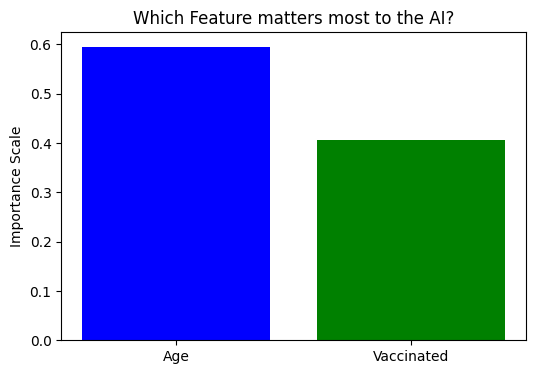

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# 1. DATA GENERATION
np.random.seed(42)
n_people = 1000
ages = np.random.randint(1, 90, n_people)
vaccinated = np.random.choice([0, 1], size=n_people, p=[0.5, 0.5])

recovered = []
for i in range(n_people):
    if vaccinated[i] == 1:
        recovered.append(np.random.choice([1, 0], p=[0.9, 0.1]))
    else:
        if ages[i] < 50:
            recovered.append(np.random.choice([1, 0], p=[0.7, 0.3]))
        else:
            recovered.append(np.random.choice([1, 0], p=[0.3, 0.7]))

village_data = pd.DataFrame({'Age': ages, 'Vaccinated': vaccinated, 'Recovered': recovered})

# 2. TRAINING THE MODEL
X = village_data[['Age', 'Vaccinated']]
y = village_data['Recovered']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

ml_model = RandomForestClassifier(random_state=42)
ml_model.fit(X_train, y_train)

# 3. FEATURE IMPORTANCE (KAWAA SHAYGA UGU MUHIIMSAN?)
importances = ml_model.feature_importances_
features = X.columns

print("--- FEATURE IMPORTANCE RATIO ---")
for feature, importance in zip(features, importances):
    print(f"{feature}: {importance * 100:.2f}%")

# 4. PLOT THE IMPORTANCE
plt.figure(figsize=(6, 4))
plt.bar(features, importances, color=['blue', 'green'])
plt.title('Which Feature matters most to the AI?')
plt.ylabel('Importance Scale')
plt.show()